# Importing Library

## Pip install thing (just to shorten the installation log)

In [16]:
# !pip install --user tensorflow==2.17
# !pip install --user matplotlib
# !pip install --user tensorflow-hub
# !pip install --user scikit-learn
# !pip install --user numpy==1.26.4 
# !pip install --user seaborn

## Importing Library

### Run this if you're on Jupyter Lab

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import seaborn as sns
import glob
import cv2
import zipfile
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential  # Sequential API for building models layer by layer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, DenseNet121
import shutil
from PIL import Image
import hashlib
import random
from pathlib import Path
from tqdm import tqdm
from tensorflow.keras.callbacks import TensorBoard, CSVLogger

import warnings
warnings.filterwarnings('ignore')

print("TF version:", tf.__version__)
# print("Hub version:", hub.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")
# Check for GPU availability in TensorFlow
device = "GPU" if len(tf.config.list_physical_devices('GPU')) > 0 else "CPU"
print("The device is:", device)

# rm -rf '/content/__MACOSX'
# use this one when you need to remove folder and not getting must be empty error

TF version: 2.17.0
GPU is NOT AVAILABLE
The device is: CPU


# Extracting Data

### Loading and Unzipping Data From Drive

In [22]:
# Define the extraction paths
train_extract_path = 'dataset/train_images/'
test_extract_path = 'dataset/test_images/'

# For train images: remove if exists, then extract
if os.path.exists(train_extract_path):
    print(f"Removing existing train images folder: {train_extract_path}")
    shutil.rmtree(train_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(train_extract_path, exist_ok=True)

# Extract train images
with zipfile.ZipFile('zip_data/train_images.zip', 'r') as train_zip_ref:
    print("Extracting train images...")
    train_zip_ref.extractall(train_extract_path)
    print("Train images extracted successfully.")

# For test images: remove if exists, then extract
if os.path.exists(test_extract_path):
    print(f"Removing existing test images folder: {test_extract_path}")
    shutil.rmtree(test_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(test_extract_path, exist_ok=True)

# Extract test images
with zipfile.ZipFile('zip_data/test_images.zip', 'r') as test_zip_ref:
    print("Extracting test images...")
    test_zip_ref.extractall(test_extract_path)
    print("Test images extracted successfully.")

print("All extraction complete!")

Removing existing train images folder: dataset/train_images/
Extracting train images...
Train images extracted successfully.
Removing existing test images folder: dataset/test_images/
Extracting test images...
Test images extracted successfully.
All extraction complete!


### Check Class Names

In [24]:
CLASS_NAMES = [os.path.basename(l) for l in glob.glob('dataset/train_images/train_images/*')
               if '.' not in l]
# CLASS_NAMES = [os.path.basename(l) for l in glob.glob('/content/drive/MyDrive/Colab Notebooks/train_images/train_images/*')
#                if '.' not in l]  ## if on google colab
print(CLASS_NAMES)

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


### Load CSV file

In [26]:
# train_df = pd.read_csv('/content/drive/MyDrive/Dataset/meta_train.csv')
train_df = pd.read_csv('opencv/meta_train.csv')
train_df

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45
...,...,...,...,...
10402,107607.jpg,tungro,Zonal,55
10403,107811.jpg,tungro,Zonal,55
10404,108547.jpg,tungro,Zonal,55
10405,110245.jpg,tungro,Zonal,55


Map the path depending on the label first

In [28]:
# train_df['path'] = '/content/drive/MyDrive/Colab Notebooks/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df['path'] = 'dataset/train_images/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...


# Data Loading and Preprocessing

### Check Duplicates in dataset

In [31]:
def calculate_hash(image_path):
    with Image.open(image_path) as img:
        return hashlib.md5(img.tobytes()).hexdigest()

def find_duplicates_in_dataset(root_folder):
    hashes = {}
    duplicates = []

    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg')):
                path = os.path.join(subdir, file)
                try:
                    file_hash = calculate_hash(path)
                    if file_hash in hashes:
                        duplicates.append((path, hashes[file_hash]))
                    else:
                        hashes[file_hash] = path
                except Exception as e:
                    print(f"Error processing {file}: {e}")
    
    return duplicates
    
# Function to delete duplicate files, keeping only the first occurrence
def remove_duplicate_files(duplicates):
    removed_count = 0
    for duplicate_path, original_path in duplicates:
        try:
            # Check if file exists before attempting to remove
            if os.path.exists(duplicate_path):
                os.remove(duplicate_path)
                print(f"Removed: {duplicate_path}")
                removed_count += 1
            else:
                print(f"File not found: {duplicate_path}")
        except Exception as e:
            print(f"Error removing {duplicate_path}: {e}")
    
    return removed_count

duplicates = find_duplicates_in_dataset('dataset/train_images/train_images/')
for dup1, dup2 in duplicates:
    print(f"Duplicate found:\n -> {dup1}\n -> {dup2}\n")

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\100513.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100169.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\103032.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100133.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\104800.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\102353.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\105878.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\103344.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\106984.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100998.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\107812.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100635.jpg

Duplicate found:
 -> dataset/train_image

Then we will remove these dulpicate ones from the dataframe
Then we need to remove it from the dataset as well.

In [33]:
# Remove the duplicate files from the filesystem
if duplicates:
    removed_count = remove_duplicate_files(duplicates)
    print(f"\nRemoved {removed_count} duplicate image files")
else:
    print("No duplicates found.")

# If you also need to update your dataframe after removing files
if 'train_df' in locals() or 'train_df' in globals():
    # Extract ONLY the duplicate paths (not the originals) to remove from dataframe
    paths_to_remove = [duplicate_path for duplicate_path, original_path in duplicates]
    
    # Normalize paths to ensure consistent comparison
    train_df['path'] = train_df['path'].apply(os.path.normpath)
    paths_to_remove = [os.path.normpath(path) for path in paths_to_remove]
    
    # Remove only the duplicate entries from dataframe
    original_length = len(train_df)
    train_df = train_df[~train_df['path'].isin(paths_to_remove)].reset_index(drop=True)
    removed_count = original_length - len(train_df)
    
    print(f"Removed {removed_count} duplicate image entries from dataframe")

Removed: dataset/train_images/train_images/bacterial_leaf_blight\100513.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\103032.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\104800.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\105878.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\106984.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\107812.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\108125.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\108353.jpg
Removed: dataset/train_images/train_images/bacterial_panicle_blight\104803.jpg
Removed: dataset/train_images/train_images/blast\102705.jpg
Removed: dataset/train_images/train_images/blast\105626.jpg
Removed: dataset/train_images/train_images/blast\105840.jpg
Removed: dataset/train_images/train_images/blast\105962.jpg
Removed: dataset/train_images/train_images/blast\106520.jpg
Removed: data

### Sorted into folder according to their variety

In [35]:
# Define output directory
output_base_dir = 'dataset/train_images_by_variety'

# Reset the output directory if it exists
if os.path.exists(output_base_dir):
    shutil.rmtree(output_base_dir)
    print(f"Removed existing directory: {output_base_dir}")

# Recreate the base output directory
os.makedirs(output_base_dir, exist_ok=True)

# Get unique varieties
varieties = train_df['variety'].unique()
print(f"Found {len(varieties)} unique varieties: {varieties}")

# Create directories for each variety
for variety in varieties:
    variety_dir = os.path.join(output_base_dir, variety)
    os.makedirs(variety_dir, exist_ok=True)

# Copy files to their new locations
print("Copying images to variety folders...")
for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    src_path = row['path']
    dst_path = os.path.join(output_base_dir, row['variety'], row['image_id'])
    
    try:
        shutil.copy2(src_path, dst_path)
    except FileNotFoundError:
        print(f"Warning: Could not find {src_path}")

print("Done. Images have been sorted into directories by variety.")
print(f"New directory structure: {output_base_dir}/[variety]/[image_id]")

# Verify image count per variety
for variety in varieties:
    variety_dir = os.path.join(output_base_dir, variety)
    file_count = len([f for f in os.listdir(variety_dir) if os.path.isfile(os.path.join(variety_dir, f))])
    print(f"Variety '{variety}': {file_count} images")


Removed existing directory: dataset/train_images_by_variety
Found 10 unique varieties: ['ADT45' 'IR20' 'KarnatakaPonni' 'Onthanel' 'Ponni' 'Surya' 'Zonal'
 'AndraPonni' 'AtchayaPonni' 'RR']
Copying images to variety folders...


100%|███████████████████████████████████████████████████████████████████████████| 10333/10333 [00:10<00:00, 994.14it/s]


Done. Images have been sorted into directories by variety.
New directory structure: dataset/train_images_by_variety/[variety]/[image_id]
Variety 'ADT45': 6930 images
Variety 'IR20': 113 images
Variety 'KarnatakaPonni': 982 images
Variety 'Onthanel': 349 images
Variety 'Ponni': 656 images
Variety 'Surya': 32 images
Variety 'Zonal': 399 images
Variety 'AndraPonni': 376 images
Variety 'AtchayaPonni': 460 images
Variety 'RR': 36 images


### Map the csv depending on the variety

In [37]:
train_df = train_df.drop('path', axis=1)
train_df['path'] = 'dataset/train_images_by_variety/' + train_df['variety'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/101918.jpg


In [38]:
train_df

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/101918.jpg
...,...,...,...,...,...
10328,107607.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/107607.jpg
10329,107811.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/107811.jpg
10330,108547.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/108547.jpg
10331,110245.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/110245.jpg


### Data Distribution

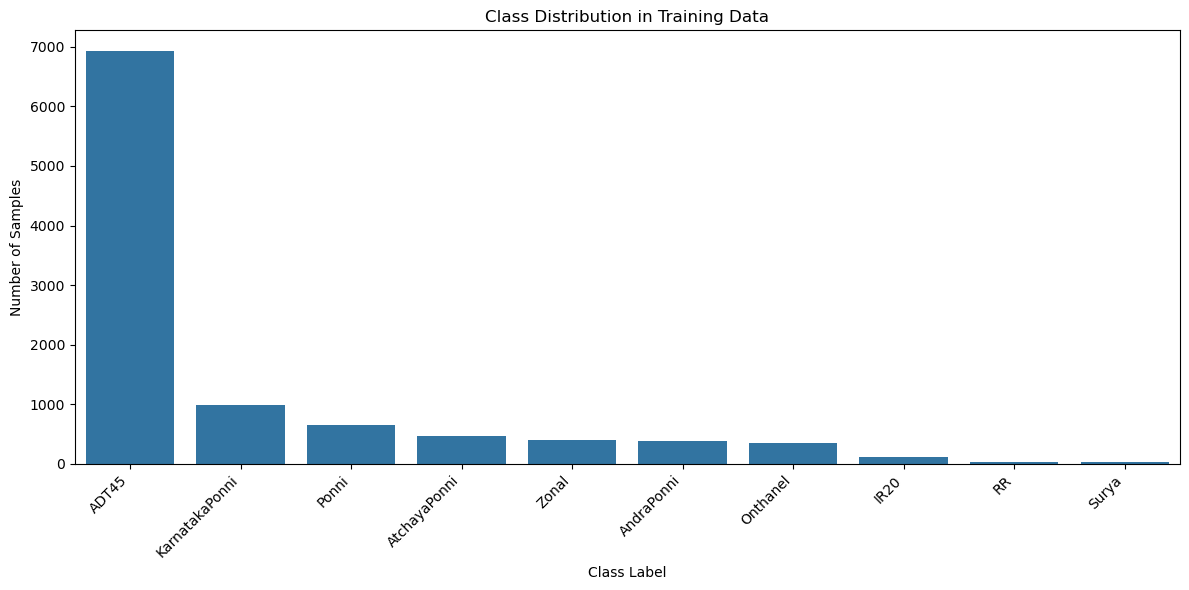

Class distribution:
ADT45: 6930 samples (67.07%)
KarnatakaPonni: 982 samples (9.50%)
Ponni: 656 samples (6.35%)
AtchayaPonni: 460 samples (4.45%)
Zonal: 399 samples (3.86%)
AndraPonni: 376 samples (3.64%)
Onthanel: 349 samples (3.38%)
IR20: 113 samples (1.09%)
RR: 36 samples (0.35%)
Surya: 32 samples (0.31%)


In [40]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
class_counts = train_df['variety'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the exact counts
print("Class distribution:")
for variety, count in class_counts.items():
    print(f"{variety}: {count} samples ({count/len(train_df)*100:.2f}%)")

In [41]:
def check_total_images(data_dir):
    """
    Prints the number of images per class and the total in the dataset directory.
    """
    total = 0
    print("Image Count Per Class:")
    print("-" * 30)
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        total += count
        print(f"{class_name:25}: {count} images")
    print("-" * 30)
    print(f"Total images in dataset: {total}")

check_total_images('dataset/train_images_by_variety/')

Image Count Per Class:
------------------------------
ADT45                    : 6930 images
AndraPonni               : 376 images
AtchayaPonni             : 460 images
IR20                     : 113 images
KarnatakaPonni           : 982 images
Onthanel                 : 349 images
Ponni                    : 656 images
RR                       : 36 images
Surya                    : 32 images
Zonal                    : 399 images
------------------------------
Total images in dataset: 10333


## Augmentating the Data before Splitting and Loading

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
import os
import numpy as np
from tqdm import tqdm

train_data_path = 'dataset/train_images_by_variety/'

# Step 1: Count images per class
class_counts = {}
for class_name in os.listdir(train_data_path):
    class_path = os.path.join(train_data_path, class_name)
    if not os.path.isdir(class_path): continue
    image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    class_counts[class_name] = len(image_files)

# Step 2: Define augmentation
augmentor = ImageDataGenerator(
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest'
)

average_count = int(np.mean(list(class_counts.values())))
print(f"Target image count per class: {average_count}")

# Step 3: Augment classes below the average
for class_name, count in class_counts.items():
    if count >= average_count:
        print(f"Skipping '{class_name}' (already has {count} images)")
        continue

    class_path = os.path.join(train_data_path, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    current_count = count
    augment_index = 0

    print(f"Augmenting '{class_name}' from {current_count} to {average_count}")
    pbar = tqdm(total=average_count - current_count)

    while current_count < average_count:
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = load_img(img_path)
            x = img_to_array(img).reshape((1,) + img_to_array(img).shape)

            batch = next(augmentor.flow(x, batch_size=1))
            new_img = array_to_img(batch[0])
            new_img.save(os.path.join(class_path, f'aug_{augment_index}.jpg'))

            current_count += 1
            augment_index += 1
            pbar.update(1)

            if current_count >= average_count:
                break

    pbar.close()


Target image count per class: 1033
Skipping 'ADT45' (already has 6930 images)
Augmenting 'AndraPonni' from 376 to 1033


100%|████████████████████████████████████████████████████████████████████████████████| 657/657 [01:03<00:00, 10.27it/s]


Augmenting 'AtchayaPonni' from 460 to 1033


100%|████████████████████████████████████████████████████████████████████████████████| 573/573 [00:55<00:00, 10.33it/s]


Augmenting 'IR20' from 113 to 1033


...

100%|████████████████████████████████████████████████████████████████████████████████| 997/997 [01:34<00:00, 10.52it/s]


Augmenting 'Surya' from 32 to 1033


100%|██████████████████████████████████████████████████████████████████████████████| 1001/1001 [01:37<00:00, 10.30it/s]


Augmenting 'Zonal' from 399 to 1033


100%|████████████████████████████████████████████████████████████████████████████████| 634/634 [01:05<00:00,  9.65it/s]


### Data Normalization and Data Generator

In [45]:
check_total_images('dataset/train_images_by_variety/')

Image Count Per Class:
------------------------------
ADT45                    : 6930 images
AndraPonni               : 1033 images
AtchayaPonni             : 1033 images
IR20                     : 1033 images
KarnatakaPonni           : 1033 images
Onthanel                 : 1033 images
Ponni                    : 1033 images
RR                       : 1033 images
Surya                    : 1033 images
Zonal                    : 1033 images
------------------------------
Total images in dataset: 16227


In [46]:
BATCH_SIZE = 32
IMAGE_SHAPE = (224,224)
train_data_path = 'dataset/train_images_by_variety/'

# For training data - with augmentation
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

With these parameters as data augmentation parameters, I split the dataset with the reatio of 0.8-0.2.

In [48]:
# For training data (with augmentation)
train_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='training',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 12987 images belonging to 10 classes.


In [49]:
# For validation data (without augmentation)
valid_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='validation',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 3240 images belonging to 10 classes.


## Data Distribution After Augmentated

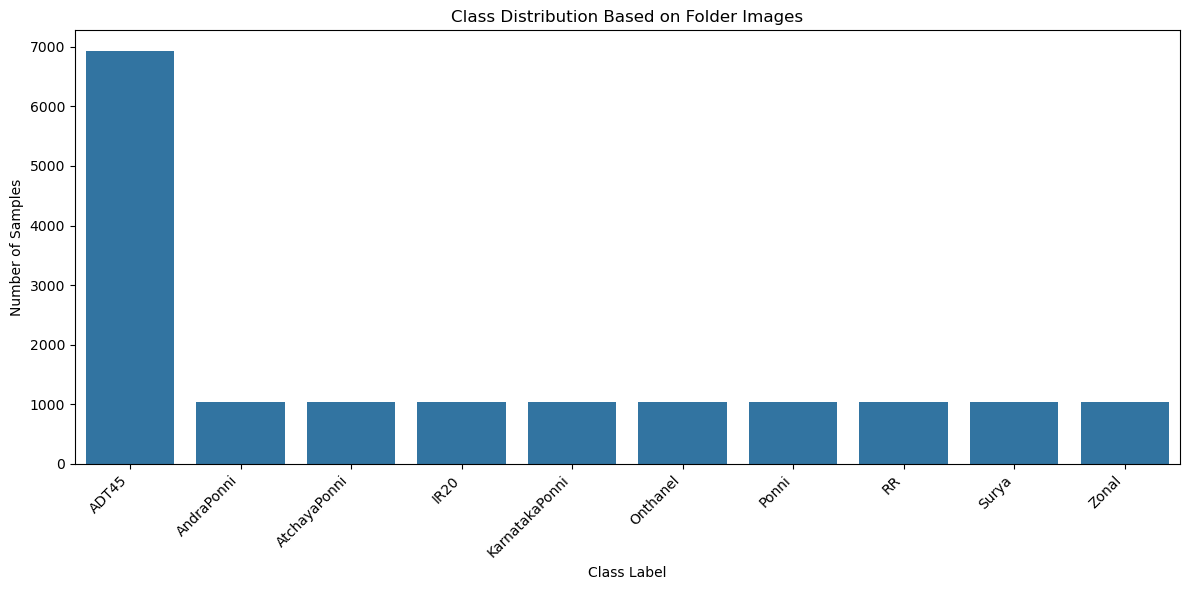

Updated Class Distribution:
ADT45: 6930 samples (42.71%)
AndraPonni: 1033 samples (6.37%)
AtchayaPonni: 1033 samples (6.37%)
IR20: 1033 samples (6.37%)
KarnatakaPonni: 1033 samples (6.37%)
Onthanel: 1033 samples (6.37%)
Ponni: 1033 samples (6.37%)
RR: 1033 samples (6.37%)
Surya: 1033 samples (6.37%)
Zonal: 1033 samples (6.37%)


In [51]:
from collections import Counter

folder_counts = {}
for class_name in os.listdir(train_data_path):
    class_folder = os.path.join(train_data_path, class_name)
    if os.path.isdir(class_folder):
        count = len([f for f in os.listdir(class_folder) if f.endswith('.jpg')])
        folder_counts[class_name] = count

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(folder_counts.keys()), y=list(folder_counts.values()))
plt.title('Class Distribution Based on Folder Images')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print counts
print("Updated Class Distribution:")
total_imgs = sum(folder_counts.values())
for label, count in folder_counts.items():
    print(f"{label}: {count} samples ({(count/total_imgs)*100:.2f}%)")


### Data Class Weighting

Calculate class weighting on the dataframe

In [54]:
def get_class_counts_from_folders(data_dir):
    """
    Returns a dictionary with image counts per class folder.
    """
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        class_counts[class_name] = count
    return class_counts

def calculate_class_weights(class_counts):
    """
    Calculates class weights inversely proportional to class frequencies.
    """
    total_samples = sum(class_counts.values())
    num_classes = len(class_counts)
    class_weights = {}

    for class_name, count in class_counts.items():
        class_weights[class_name] = total_samples / (num_classes * count)

    print("Class weights:")
    for class_name, weight in class_weights.items():
        print(f"Class '{class_name}': {weight:.4f}")

    return class_weights

def map_weights_to_generator_indices(class_weights, generator_class_indices):
    """
    Maps class weights (based on class names) to generator indices used during model training.
    """
    index_weights = {}

    for class_name, weight in class_weights.items():
        if class_name in generator_class_indices:
            index = generator_class_indices[class_name]
            index_weights[index] = weight
        else:
            print(f"Warning: Class '{class_name}' not found in generator indices")

    for class_name, index in generator_class_indices.items():
        if index not in index_weights:
            print(f"Warning: No weight assigned for generator class '{class_name}' (index {index})")

    return index_weights


In [55]:
# Step 1: Get counts directly from folders
class_counts = get_class_counts_from_folders(train_data_path)

# Step 2: Compute weights
class_weights = calculate_class_weights(class_counts)

# Step 3: Get generator class indices
generator_class_indices = train_gen.class_indices
print("Generator class indices:", generator_class_indices)

# Step 4: Map weights to generator indices
index_weights = map_weights_to_generator_indices(class_weights, generator_class_indices)

print("-" * 30)

# Final weights to use in model.fit()
print("Mapped index weights:")
for idx, weight in sorted(index_weights.items()):
    print(f"Index {idx}: {weight:.4f}")

Class weights:
Class 'ADT45': 0.2342
Class 'AndraPonni': 1.5709
Class 'AtchayaPonni': 1.5709
Class 'IR20': 1.5709
Class 'KarnatakaPonni': 1.5709
Class 'Onthanel': 1.5709
Class 'Ponni': 1.5709
Class 'RR': 1.5709
Class 'Surya': 1.5709
Class 'Zonal': 1.5709
Generator class indices: {'ADT45': 0, 'AndraPonni': 1, 'AtchayaPonni': 2, 'IR20': 3, 'KarnatakaPonni': 4, 'Onthanel': 5, 'Ponni': 6, 'RR': 7, 'Surya': 8, 'Zonal': 9}
------------------------------
Mapped index weights:
Index 0: 0.2342
Index 1: 1.5709
Index 2: 1.5709
Index 3: 1.5709
Index 4: 1.5709
Index 5: 1.5709
Index 6: 1.5709
Index 7: 1.5709
Index 8: 1.5709
Index 9: 1.5709


## Callback functions for training monitoring and improvement

In [57]:
class TerminateNaN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get('loss')
        if loss is not None:
            if np.isnan(loss) or np.isinf(loss):
                print(f"Invalid loss and terminated at loss {loss}; epoch: {epoch}")
                self.model.stop_training = True

terminate_nan = TerminateNaN()

In [58]:
# Save model after every epoch if the validation accuracy improves from previous epoch
cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_cnn_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

densenet_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_densenet_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

resnet50_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_resnet50_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

In [59]:
# Standard learning rate reduction on plateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_categorical_accuracy",
    factor=0.1,
    patience=3,
    verbose=1,
    mode="auto",
    min_delta=0.001,
    cooldown=1,
    min_lr=1e-6
)

In [60]:
# Early stopping with baseline performance requirement
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_categorical_accuracy',
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode='auto',
    baseline=0.75,  # Only consider stopping if accuracy is above this threshold
    restore_best_weights=True
)

In [61]:
# CSV logger to save training metrics to file
cnn_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_cnn_training_history.csv',
    separator=',',
    append=True
)

densenet_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_densenet_training_history.csv',
    separator=',',
    append=True
)

resnet50_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_resnet50_training_history.csv',
    separator=',',
    append=True
)

Tensorboard test Track metrics, images, and more with TensorBoard:

In [63]:
tensorboard_cb = TensorBoard(log_dir='logs', histogram_freq=1)

### CNN Model

In [92]:
# For Task 2: Paddy Variety Identification with in-model augmentation
num_classes= 10

cnn_model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Fourth convolutional block (slightly deeper than Task 1)
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),  # Add dropout to prevent overfitting
    # Assuming there are 5 paddy varieties (change according to your dataset)
    layers.Dense(num_classes, activation='softmax') 
])

# Compile the model
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

cnn_model.build(input_shape=(None, 224, 224, 3))

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,086,090 (99.51 MB)

 Trainable params: 26,085,130 (99.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
cnn_history = model.fit(
    train_gen,
    batch_size = batch_size,
    validation_data = valid_gen,
    epochs=200,
    verbose=1,
    class_weight=index_weights,
    callbacks=[terminate_nan, cnn_checkpoint, reduce_lr, early_stopping, cnn_csv_logger,tensorboard_cb]
)

### DenseNet Model

In [94]:
# Load DenseNet121 for training from scratch
base_model = DenseNet121(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

# Keep all layers trainable since we're training from scratch
base_model.trainable = True

# Create the full model
densenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),  # Increased neurons for better capacity
    layers.BatchNormalization(),
    layers.Dropout(0.3),  # Additional dropout for regularization
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(num_classes, activation='softmax')  # Replace with your actual number of classes
])

# Compile with appropriate parameters for training from scratch
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

densenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)             │ (None, 7, 7, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,335,626 (27.98 MB)

 Trainable params: 7,251,210 (27.66 MB)

 Non-trainable params: 84,416 (329.75 KB)

In [ ]:
densenet_history = model.fit(
    train_gen,
    batch_size = batch_size,
    validation_data = valid_gen,
    epochs=200,
    verbose=1,
    class_weight=index_weights,
    callbacks=[terminate_nan, densenet_checkpoint, reduce_lr, early_stopping, densenet_csv_logger,tensorboard_cb]
)

### ResNet Model

In [96]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Model, layers, Input

# Base ResNet50
base_model = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# Input
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs)
x = layers.GlobalAveragePooling2D()(x)

# Feature extractor
features = layers.Dense(512, activation='relu')(x)
features = layers.BatchNormalization()(features)
features = layers.Dropout(0.5)(features)

# Attention
attention_weights = layers.Dense(512, activation='sigmoid', name='attention_weights')(features)
attention_output = layers.Multiply()([features, attention_weights])  # Use list!

# Classifier
x = layers.Dense(256, activation='relu')(attention_output)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

# Build Model
resnet50_model = Model(inputs=inputs, outputs=outputs)

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Display model summary
resnet50_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 7, 7, 2048)        │      23,587,712 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_1    │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 512)               │       1,049,088 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 512)               │           2,048 │ dense_5[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 512)               │               0 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_weights (Dense)     │ (None, 512)               │         262,656 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 512)               │               0 │ dropout_3[0][0],           │
│                               │                           │                 │ attention_weights[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 256)               │         131,328 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 256)               │               0 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 10)                │           2,570 │ dropout_4[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 25,035,402 (95.50 MB)

 Trainable params: 24,981,258 (95.30 MB)

 Non-trainable params: 54,144 (211.50 KB)

In [ ]:
resnet50_history = resnet50_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=200,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 32,
    callbacks=[
        terminate_nan,  # Your custom callback to catch NaN values
        resnet50_checkpoint,  # Your specific model checkpoint for ResNet50
        reduce_lr,  # Your learning rate reduction callback
        early_stopping,  # Your early stopping callback
        resnet50_csv_logger  # Your CSV logger for ResNet50
    ]
)

### Evaluation Function

In [ ]:
def evaluate_model(history):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['categorical_accuracy'], label='Train Accuracy')
    if 'val_categorical_accuracy' in history.history:
        plt.plot(history.history['val_categorical_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

For CNN Model

In [ ]:
cnn_val_acc = evaluate_model(cnn_history)

For DenseNet Model

In [ ]:
densenet_val_acc = evaluate_model(cnn_history)

For Resnet Model

In [ ]:
resnet_val_acc = evaluate_model(resnet50_history)

Check best model

In [ ]:
histories = {
    "CNN": cnn_history,
    "DenseNet": densenet_history,
    "ResNet50": resnet50_history,
}

def find_best_model(histories, task_type='classification'):
    """
    histories: dict with model names as keys and History objects as values
    task_type: 'classification' or 'regression'
    """
    best_score = -float('inf') if task_type == 'classification' else float('inf')
    best_model = None

    for name, hist in histories.items():
        if task_type == 'classification':
            val_acc = max(hist.history.get('val_categorical_accuracy', [0]))
            print(f"{name}: Best Val Accuracy = {val_acc:.4f}")
            if val_acc > best_score:
                best_score = val_acc
                best_model = name
        elif task_type == 'regression':
            val_mae = min(hist.history.get('val_mae', [float('inf')]))
            print(f"{name}: Best Val MAE = {val_mae:.4f}")
            if val_mae < best_score:
                best_score = val_mae
                best_model = name

    print(f"\nBest model: {best_model} with {'accuracy' if task_type == 'classification' else 'MAE'} = {best_score:.4f}")
    return best_model